In [ ]:
## https://www.pexels.com/

### Object Detection with YOLO (Ultralytics)
**Part A:** run a pretrained YOLO model — real object detection out of the box, no training needed.
**Part B:** fine-tune it on a small dataset, matching the same transfer-learning workflow from
the CNN notebook (frozen/pretrained backbone → adapt to new data), evaluated with **mAP**
instead of accuracy — see the R-CNN family lecture notes for what mAP means.

Library: [Ultralytics](https://docs.ultralytics.com/) — a single pip package that wraps YOLO
training, validation, and inference. No Kaggle account or manual auth needed; pretrained
weights download automatically from GitHub the first time you use them.

#### Install & Import
`ultralytics` pulls in its own compatible PyTorch — this is a PyTorch-based library, unlike
the CNN notebook's TensorFlow/Keras code. There isn't a mature, actively-maintained
TensorFlow-native equivalent for YOLO with this level of polish (see the earlier discussion
on why Faster R-CNN/YOLO tooling is stronger on the PyTorch side).

In [2]:
pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 8.5 MB/s eta 0:00:00


In [3]:
# !pip install ultralytics   # uncomment if not already installed

from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2


Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


## Part A — Run a Pretrained Model (No Training)

#### Load a pretrained YOLO model
`yolov8n.pt` — the "nano" size, smallest and fastest YOLOv8 variant, pretrained on the full
COCO dataset (80 classes: person, car, dog, pizza, ...). The weights download automatically
the first time this runs (a few MB, from Ultralytics' GitHub releases).

In [4]:
model = YOLO('yolov8n.pt')
print(model.names)   # the 80 COCO classes this model already knows


{0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 66: 'keyboard', 67: 'cell phone', 68: 'microw

#### Run inference on an image
Point this at any image path or URL. Ultralytics handles resizing, preprocessing, and
non-max suppression internally — you get back boxes, class labels, and confidence scores
directly.

In [5]:
# Replace with your own image path, or use one of Ultralytics' sample images:
results = model('https://ultralytics.com/images/bus.jpg')

r = results[0]
print(f"Detected {len(r.boxes)} objects:")
for box in r.boxes:
    cls_id = int(box.cls[0])
    conf = float(box.conf[0])
    print(f"  {model.names[cls_id]:<15} confidence={conf:.2f}")



image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 10.8ms
Speed: 177.5ms preprocess, 10.8ms inference, 37.6ms postprocess per image at shape (1, 3, 640, 480)
Detected 6 objects:
  bus             confidence=0.87
  person          confidence=0.87
  person          confidence=0.85
  person          confidence=0.83
  person          confidence=0.26
  stop sign       confidence=0.26


#### Visualize the detections
`.plot()` draws the boxes, labels, and confidence scores directly onto the image.

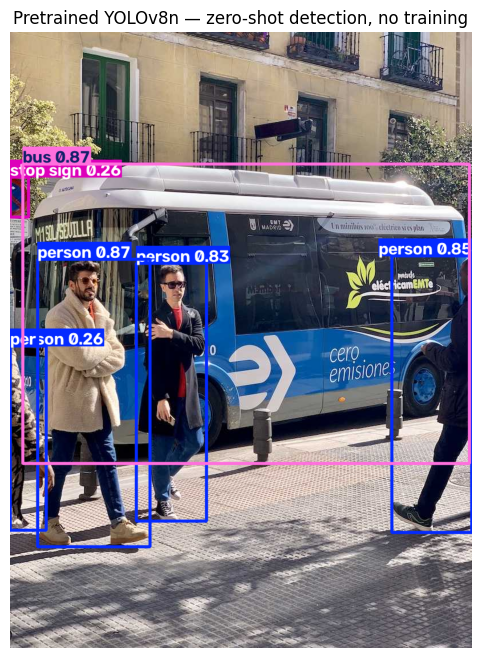

In [6]:
annotated = r.plot()  # returns a numpy array (BGR) with boxes drawn
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title("Pretrained YOLOv8n — zero-shot detection, no training")
plt.show()


## Part B — Fine-Tuning on a New Dataset
Same transfer-learning idea as the CNN notebook: start from COCO-pretrained weights
(already knows edges, shapes, common object parts) instead of random initialization, then
adapt to new data.

**Dataset**: [COCO128](https://docs.ultralytics.com/datasets/detect/coco128/) — a small
128-image subset of COCO, already in the exact folder + label format Ultralytics expects.
It ships as a built-in config, so pointing `data='coco128.yaml'` at training auto-downloads
it (~7MB) the first time.

**Important**: COCO128 uses the SAME 80 classes the pretrained model already knows — it's
used here purely to demonstrate the fine-tuning MECHANICS without requiring you to label your
own images first. For a real project, swap `data='coco128.yaml'` for a YAML pointing at your
own annotated images and class names — every other line of code stays identical. See the
[Ultralytics dataset format docs](https://docs.ultralytics.com/datasets/detect/) for how to
structure your own labeled data.

#### Look at what a YOLO dataset config actually contains
Just paths to image folders + a class name list — one label `.txt` file per image, one line
per object: `class_id  x_center  y_center  width  height` (all normalized 0-1).

In [7]:
import yaml
from ultralytics.utils import DATASETS_DIR

# print the built-in coco128 config Ultralytics ships with the package
import ultralytics, os
cfg_path = os.path.join(os.path.dirname(ultralytics.__file__), 'cfg', 'datasets', 'coco128.yaml')
with open(cfg_path) as f:
    print(f.read())


# Ultralytics 🚀 AGPL-3.0 License - https://ultralytics.com/license

# COCO128 dataset https://www.kaggle.com/datasets/ultralytics/coco128 (first 128 images from COCO train2017) by Ultralytics
# Documentation: https://docs.ultralytics.com/datasets/detect/coco128
# Example usage: yolo train data=coco128.yaml
# parent
# ├── ultralytics
# └── datasets
#     └── coco128 ← downloads here (7 MB)

# Train/val/test sets as 1) dir: path/to/imgs, 2) file: path/to/imgs.txt, or 3) list: [path/to/imgs1, path/to/imgs2, ..]
path: coco128 # dataset root dir
train: images/train2017 # train images (relative to 'path') 128 images
val: images/train2017 # val images (relative to 'path') 128 images
test: # test images (optional)

# Classes
names:
  0: person
  1: bicycle
  2: car
  3: motorcycle
  4: airplane
  5: bus
  6: train
  7: truck
  8: boat
  9: traffic light
  10: fire hydrant
  11: stop sign
  12: parking meter
  13: bench
  14: bird
  15: cat
  16: dog
  17: horse
  18: sheep
  19: cow
  20: elep

#### Fine-tune
Starts from the SAME pretrained `yolov8n.pt` weights loaded in Part A and continues training
on COCO128. `epochs` and `imgsz` are kept small here so this finishes quickly — increase both
for a real training run.

In [8]:
model = YOLO('yolov8n.pt')   # start from pretrained COCO weights, same as Part A

results = model.train(
    data="african-wildlife.yaml",   # swap this for your own dataset YAML on a real project
    epochs=5,
    imgsz=320,
    batch=16,
    verbose=True,
)


Ultralytics 8.4.156 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=african-wildlife.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=None, opset=None, optimize=False, opt

#### Evaluate with mAP
Object detection uses **mAP** (mean Average Precision), not accuracy — see the R-CNN family
notes for the full definition. `mAP50` uses an IoU threshold of 0.5; `mAP50-95` averages over
IoU thresholds from 0.5 to 0.95 (stricter, the standard COCO benchmark metric).

In [9]:
metrics = model.val()
print(f"mAP50    = {metrics.box.map50:.3f}")
print(f"mAP50-95 = {metrics.box.map:.3f}")


Ultralytics 8.4.156 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1382.7±1076.4 MB/s, size: 99.8 KB)
val: Scanning /content/datasets/african-wildlife/labels/val.cache... 225 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 225/225 55.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 7.0it/s 2.1s
                   all        225        379      0.858       0.81      0.866      0.671
               buffalo         62         89      0.943      0.746      0.876       0.68
              elephant         53         91      0.831      0.747      0.835      0.649
                 rhino         55         85      0.834      0.918      0.864      0.688
                 zebra         59        114      0.825      0.828      0.888      0.666
Speed: 0.6ms preprocess, 3.0ms 

#### Run the fine-tuned model on a new image


image 1/1 C:\Users\svika\Downloads\Machine Learning\Computer Vision\datasets\african-wildlife\images\test\2 (62).jpg: 256x320 3 elephants, 35.0ms
Speed: 1.0ms preprocess, 35.0ms inference, 0.8ms postprocess per image at shape (1, 3, 256, 320)


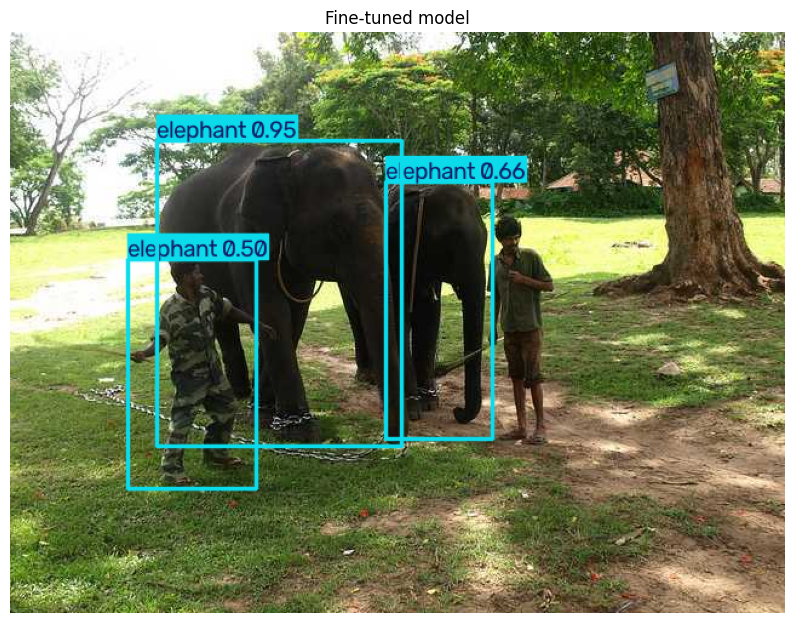

In [ ]:
results = model(r"C:\Users\svika\Downloads\Machine Learning\Computer Vision\datasets\african-wildlife\images\test\2 (62).jpg")
r = results[0]

annotated = r.plot()
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title("Fine-tuned model")
plt.show()


#### Summary
- **Part A** showed a pretrained detector working immediately — zero training, real boxes
  and classes, because it was already trained on COCO's 80 classes.
- **Part B** showed the fine-tuning workflow: same pretrained starting point, `model.train()`
  on a dataset YAML, evaluate with mAP instead of accuracy.
- **To adapt this to your own project**: replace COCO128 with your own labeled images —
  same folder structure (`images/`, `labels/`), same YAML format, same three-line training
  call. That's the entire difference between this demo and a real custom object detector.

In [ ]:
## import ultralytics, os
## cfg_path = os.path.join(os.path.dirname(ultralytics.__file__), 'cfg', 'datasets', 'coco128.yaml')
## <your Python env>\Lib\site-packages\ultralytics\cfg\datasets\coco128.yaml



In [ ]:
# my_dataset/
# ├── images/
# │   ├── train/       ← training images (.jpg/.png)
# │   └── val/         ← validation images
# └── labels/
#     ├── train/       ← one .txt file per image, SAME filename
#     └── val/

# path: /full/path/to/my_dataset
# train: images/train
# val: images/val

# names:
#   0: my_class_one
#   1: my_class_two
#   ... one line per class, starting at 0


# model = YOLO('yolov8n.pt')          # unchanged — same pretrained starting point
# results = model.train(
#     data='my_dataset.yaml',          # <-- this is the ONLY line that changes
#     epochs=50,                        # more epochs than the coco128 demo (5 was just a quick test)
#     imgsz=640,                        # 320 was for speed; 640 is standard for real training
#     batch=16,
# )